In [1]:
# !pip install torch transformers accelerate datasets scikit-learn numpy evidently matplotlib

import argparse
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

#################################
# Parse Arguments
#################################
def parse_args():
    parser = argparse.ArgumentParser(
        description="Run CLS token drift detection experiments with a true domain shift."
    )
    parser.add_argument("--model_name", type=str,
                        default="nlpaueb/sec-bert-base",
                        help="HuggingFace model name (SEC-BERT variant).")
    parser.add_argument("--wiki_dataset_name", type=str, default="wikitext",
                        help="HuggingFace dataset for original text.")
    parser.add_argument("--wiki_dataset_config", type=str,
                        default="wikitext-2-raw-v1", help="Dataset config.")
    parser.add_argument("--wiki_split", type=str, default="train",
                        help="WikiText dataset split.")
    parser.add_argument("--financial_dataset_name", type=str,
                        default="financial_phrasebank",
                        help="HuggingFace dataset for financial domain.")
    parser.add_argument("--financial_dataset_config", type=str,
                        default="sentences_50agree",
                        help="Configuration of financial_phrasebank.")
    parser.add_argument("--financial_split", type=str, default="train",
                        help="Financial dataset split.")
    parser.add_argument("--max_texts", type=int, default=30000,
                        help="Max number of texts to use from dataset.")
    parser.add_argument("--batch_size", type=int, default=64,
                        help="Batch size.")
    parser.add_argument("--alpha", type=float, default=0.01,
                        help="Alpha for running mean/cov updates.")
    parser.add_argument("--drift_threshold_std", type=float, default=3.0,
                        help="Number of std devs for threshold.")
    parser.add_argument("--window_size", type=int, default=50,
                        help="Rolling window size for threshold computation.")
    parser.add_argument("--output_dir", type=str, default="results",
                        help="Directory to save results and plots.")
    args, unknown = parser.parse_known_args()
    return args

args = parse_args()

#################################
# Setup
#################################
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# Ensure output directory exists
os.makedirs(args.output_dir, exist_ok=True)

#################################
# Load Model and Tokenizer
#################################
print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(args.model_name)
model = AutoModelForSequenceClassification.from_pretrained(args.model_name)
model.to(device)
model.eval()
print("Model ready on device:", device)

#################################
# Load Original (WikiText) Dataset
#################################
wiki_dataset = load_dataset(args.wiki_dataset_name, args.wiki_dataset_config,
                            split=args.wiki_split)
texts = wiki_dataset["text"]

if args.max_texts > 0 and args.max_texts < len(texts):
    texts = texts[:args.max_texts]
print(f"Original dataset loaded: {len(texts)} WikiText samples")

#################################
# Load Financial Dataset for Drift
#################################
fin_dataset = load_dataset(args.financial_dataset_name,
                           args.financial_dataset_config,
                           split=args.financial_split)
financial_texts = fin_dataset["sentence"]
random.shuffle(financial_texts)

# Simulate a second domain by using a slice of the financial texts as "Kaggle-like" data:
kaggle_texts = financial_texts[:1000]

print(f"Financial dataset loaded: {len(financial_texts)} samples")
print(f"Kaggle-like dataset loaded: {len(kaggle_texts)} samples")

#################################
# Simulate Multiple True Domain Drifts
#################################
n = len(texts)
drift_start_1, drift_end_1 = n // 3, n // 2
drift_start_2, drift_end_2 = 2 * n // 3, 5 * n // 6

fin_idx = 0
for i in range(drift_start_1, drift_end_1):
    texts[i] = financial_texts[fin_idx % len(financial_texts)]
    fin_idx += 1

kaggle_idx = 0
for i in range(drift_start_2, drift_end_2):
    texts[i] = kaggle_texts[kaggle_idx % len(kaggle_texts)]
    kaggle_idx += 1

print("Simulated multiple domain drifts:")
print(f"  Drift region 1: indices {drift_start_1} to {drift_end_1} (Finance).")
print(f"  Drift region 2: indices {drift_start_2} to {drift_end_2} (Kaggle).")

#################################
# Utility Functions
#################################
def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model.bert(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.mean(dim=0).cpu().numpy()

/Users/jasper.bruin/miniconda3/envs/driftwatch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
Loading model and tokenizer...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/sec-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model ready on device: mps
Original dataset loaded: 30000 WikiText samples
Financial dataset loaded: 4846 samples
Kaggle-like dataset loaded: 1000 samples
Simulated multiple domain drifts:
  Drift region 1: indices 10000 to 15000 (Finance).
  Drift region 2: indices 20000 to 25000 (Kaggle).


In [2]:
#################################
# CLEAR Implementation
#################################
baseline_embeddings = []
for batch in batch_generator(texts[:args.max_texts], args.batch_size):
    baseline_embeddings.append(extract_cls_embeddings(model, tokenizer, batch, device))
baseline_prototype = np.mean(baseline_embeddings, axis=0)

prototype = baseline_prototype
prototypes, drifts, cosine_scores = [prototype], [], []

print("Processing dataset to detect drifts...")
for i, batch in enumerate(tqdm(batch_generator(texts, args.batch_size))):
    batch_embeddings = extract_cls_embeddings(model, tokenizer, batch, device)
    if len(batch_embeddings.shape) == 1:
        batch_embeddings = batch_embeddings[np.newaxis, :]
    similarity = cosine_similarity([batch_embeddings.mean(axis=0)], [prototype])[0][0]
    cosine_scores.append(similarity)
    threshold = (np.mean(cosine_scores[-args.window_size:]) -
                 args.drift_threshold_std * np.std(cosine_scores[-args.window_size:]))
    if similarity < threshold:
        drifts.append(i * args.batch_size)
        print(f"Drift detected at batch {i}, index {i * args.batch_size}")
    delta = batch_embeddings - prototype
    weights = np.exp(-np.linalg.norm(delta, axis=1) / 2.0)
    prototype += np.sum(weights[:, None] * delta, axis=0) / np.sum(weights)
    prototypes.append(prototype)

Processing dataset to detect drifts...


50it [01:13,  1.10s/it]

Drift detected at batch 49, index 3136


91it [02:08,  1.23s/it]

Drift detected at batch 90, index 5760


...

403it [11:51,  1.91s/it]

Drift detected at batch 402, index 25728


455it [13:08,  1.62s/it]

Drift detected at batch 454, index 29056


469it [13:32,  1.73s/it]


In [3]:
# save the results that are necessary.
np.save(os.path.join(args.output_dir, "cosine_scores_bert.npy"), cosine_scores)
np.save(os.path.join(args.output_dir, "detected_drifts_cosine_bert.npy"), drifts)

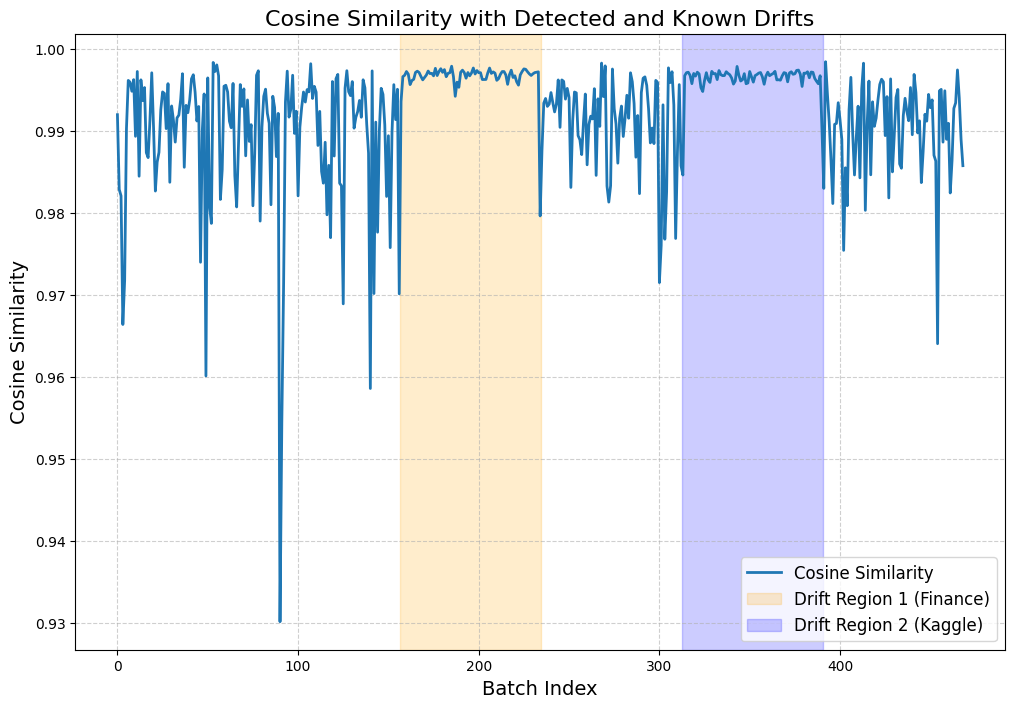

In [4]:
plt.figure(figsize=(12, 8))

# Plot cosine similarity scores
plt.plot(cosine_scores, label="Cosine Similarity", linewidth=2)

# Highlight known drift regions with shaded areas
plt.axvspan(drift_start_1 / args.batch_size, drift_end_1 / args.batch_size,
            color="orange", alpha=0.2, label="Drift Region 1 (Finance)")
plt.axvspan(drift_start_2 / args.batch_size, drift_end_2 / args.batch_size,
            color="blue", alpha=0.2, label="Drift Region 2 (Kaggle)")

# # Add vertical lines and dots for detected drifts
# for drift in drifts:
#     plt.axvline(drift / args.batch_size, color="red", linestyle="--", label="Detected Drift")
#     plt.scatter(drift / args.batch_size, cosine_scores[int(drift / args.batch_size)],
#                 color="red", zorder=5)

# Add title and labels
plt.title("Cosine Similarity with Detected and Known Drifts", fontsize=16)
plt.xlabel("Batch Index", fontsize=14)
plt.ylabel("Cosine Similarity", fontsize=14)
plt.legend(loc="best", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

# Save and display the plot
plt.savefig(os.path.join(args.output_dir, "drift_detection_plot_with_highlights.png"))
plt.show()
